100%|██████████| 9.91M/9.91M [00:02<00:00, 4.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]


Epoch: 1 Loss: 0.03397594392299652
Epoch: 2 Loss: 0.029696937650442123
Epoch: 3 Loss: 0.02595358155667782


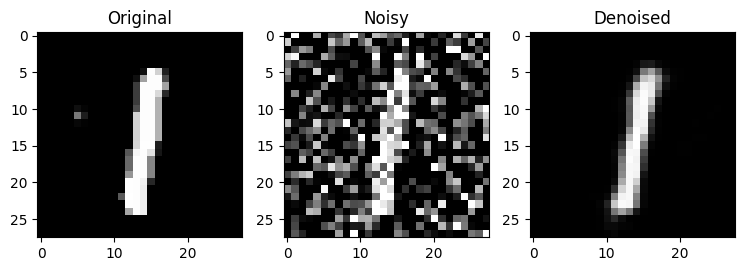

In [1]:
#10
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load MNIST Dataset
transform = transforms.ToTensor()
train_data = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# Define Denoising Autoencoder
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DenoisingAutoencoder()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
for epoch in range(3):
    for images, _ in train_loader:

        # Add Noise
        noisy_images = images + 0.5 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images, 0., 1.)

        output = model(noisy_images)
        loss = loss_fn(output, images.view(-1,28*28))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

# Testing and Display
sample = next(iter(train_loader))[0][:1]
noisy_sample = sample + 0.5 * torch.randn_like(sample)
noisy_sample = torch.clamp(noisy_sample, 0., 1.)

reconstructed = model(noisy_sample).detach()

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(sample[0][0], cmap='gray')

plt.subplot(1,3,2)
plt.title("Noisy")
plt.imshow(noisy_sample[0][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Denoised")
plt.imshow(reconstructed.view(28,28), cmap='gray')

plt.show()